Iter	T_n		f(T_n)
1	228.333333	0.000000e+00
2	228.333333	0.000000e+00

✅ Approximate solution found!

Approximate Temperature ≈ 228.3333 °C


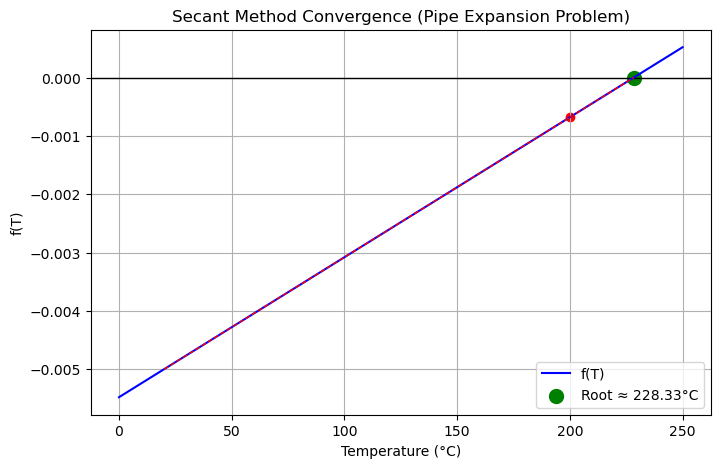

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Real-life problem: Finding temperature for metal expansion
def f(T):
    L0 = 2.0          # initial length (m)
    alpha = 0.000012  # coefficient of linear expansion (/°C)
    T0 = 20           # reference temperature (°C)
    L_target = 2.005  # desired length (m)
    return L0 * (1 + alpha * (T - T0)) - L_target

# Secant method function
def secant_method(x0, x1, tol, max_iter):
    xs = [x0, x1]  # store iterations for plotting
    print("Iter\tT_n\t\tf(T_n)")
    for i in range(max_iter):
        f0 = f(x0)
        f1 = f(x1)

        if abs(f1 - f0) < 1e-12:
            print("Error: Division by zero in iteration.")
            break

        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        xs.append(x2)

        print(f"{i+1}\t{x2:.6f}\t{f(x2):.6e}")

        if abs(x2 - x1) < tol:
            print("\n✅ Approximate solution found!")
            return x2, xs

        x0, x1 = x1, x2

    print("\n❌ Did not converge within maximum iterations.")
    return None, xs

# Initial guesses
x0 = 20   # first guess (°C)
x1 = 200  # second guess (°C)

# Run secant method
root, steps = secant_method(x0, x1, tol=1e-6, max_iter=50)

# Print result
if root:
    print(f"\nApproximate Temperature ≈ {root:.4f} °C")

# --------------------------------------------------------
# Plotting
# --------------------------------------------------------

# Range for plotting
T_vals = np.linspace(0, 250, 200)
f_vals = [f(T) for T in T_vals]

plt.figure(figsize=(8,5))
plt.axhline(0, color='black', linewidth=1)  # x-axis
plt.plot(T_vals, f_vals, label='f(T)', color='blue')

# Plot secant method steps
for i in range(len(steps)-1):
    plt.plot([steps[i], steps[i+1]], [f(steps[i]), f(steps[i+1])],
             'r--', linewidth=1)
    plt.scatter(steps[i+1], f(steps[i+1]), color='red')

# Highlight final root
if root:
    plt.scatter(root, 0, color='green', s=100, label=f'Root ≈ {root:.2f}°C')

plt.title("Secant Method Convergence (Pipe Expansion Problem)")
plt.xlabel("Temperature (°C)")
plt.ylabel("f(T)")
plt.legend()
plt.grid(True)
plt.show()
